# SECTOR ANALYSIS - Basic Materials

check if makes sense: https://www.spglobal.com/spdji/en/index-family/equity/us-equity/sp-sectors/#overview


In [1]:
import pandas as pd
from pathlib import Path
import os

os.chdir(Path.cwd().parent.parent)

sector_name = "Basic Materials"


In [2]:
df = pd.read_csv("backtest/data/backtest_data.csv")
df = df[df["sector"] == sector_name]

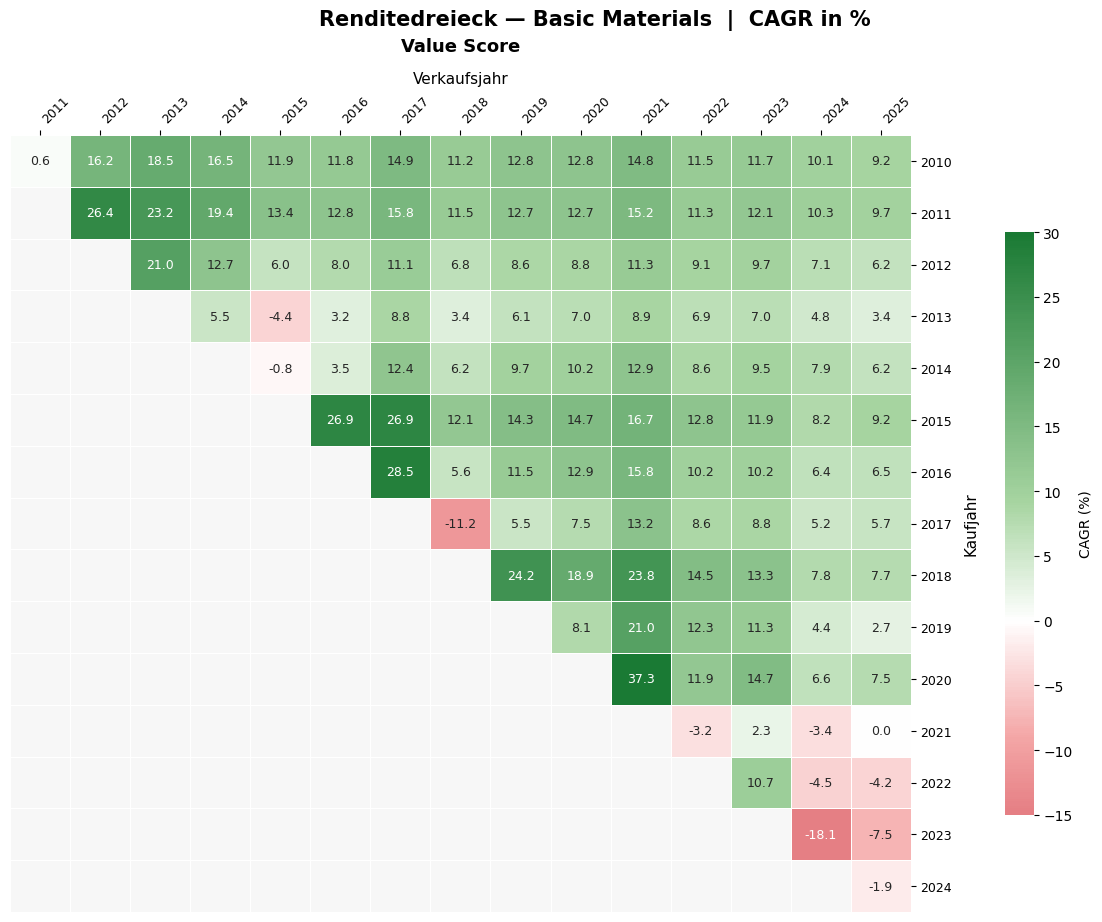

In [3]:
from backtest.renditedreieck import plot_renditedreieck

plot_renditedreieck(df, sector_name, "value_score", label="Value Score")

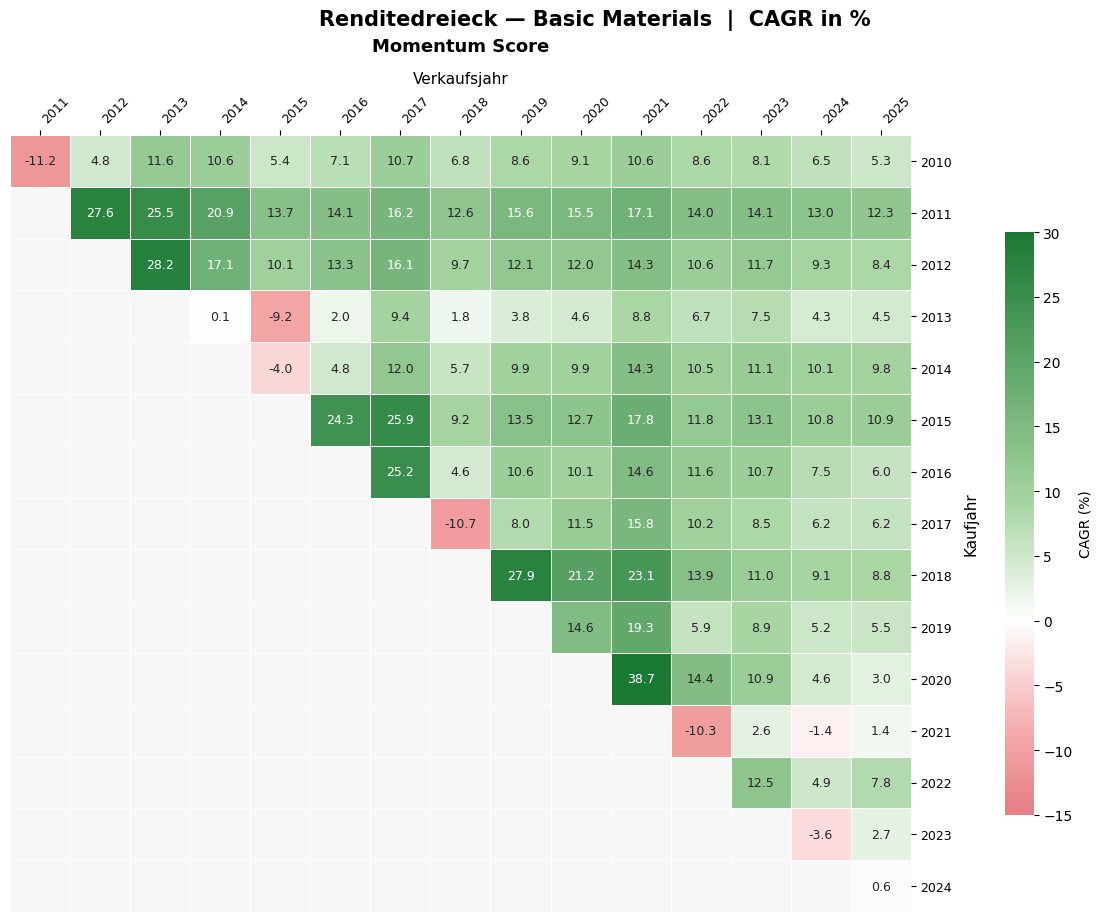

In [4]:
plot_renditedreieck(df, sector_name, "momentum_score", label="Momentum Score")

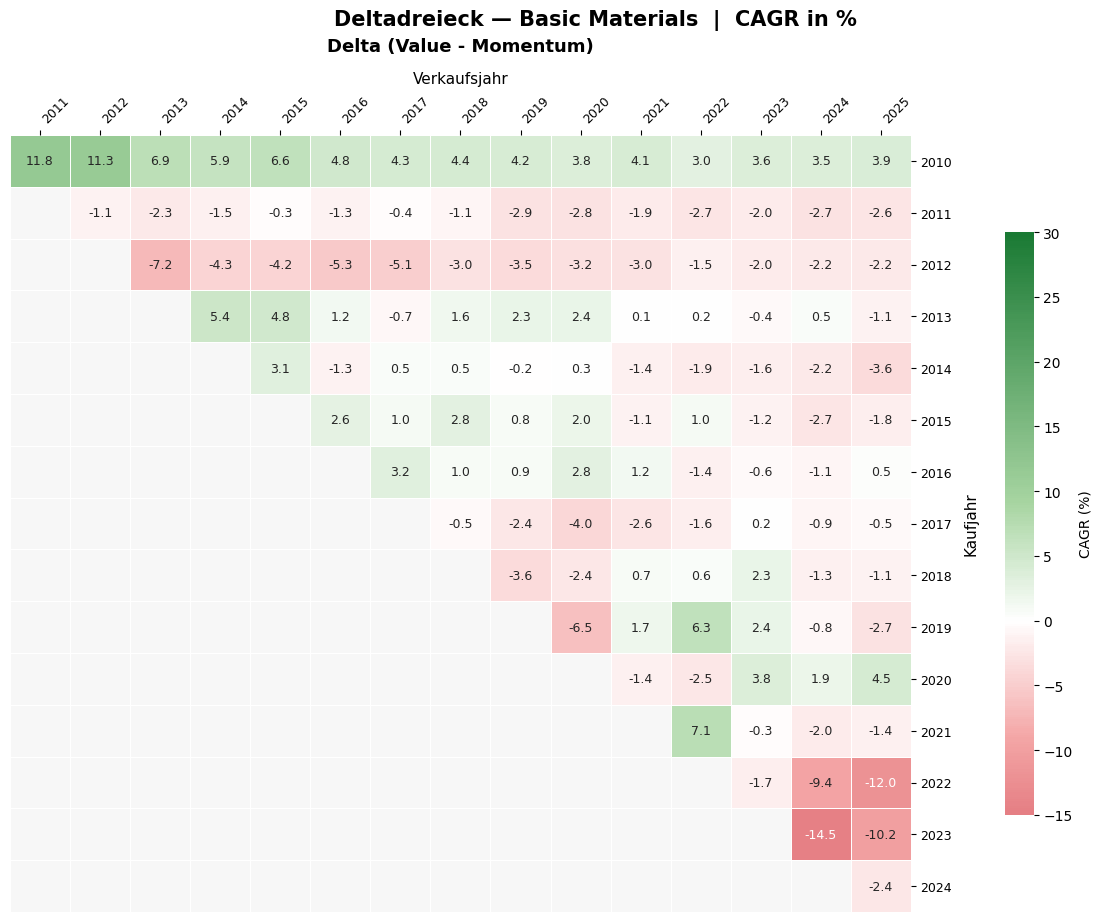

In [5]:

df_value = df[df["strategy"] == "value_score"].set_index(["buyyear", "sellyear", "sector"])["rendite"]
df_mom   = df[df["strategy"] == "momentum_score"].set_index(["buyyear", "sellyear", "sector"])["rendite"]


df_delta = (df_value - df_mom).reset_index()
df_delta.columns = ["buyyear", "sellyear", "sector", "rendite"]
df_delta["strategy"] = "delta"  # damit plot_renditedreieck funktioniert

plot_renditedreieck(df_delta, sector_name, "delta", label="Delta (Value - Momentum)", titel="Deltadreieck")


## 1, 3, 5 Jahres Ansicht


In [6]:
import plotly.express as px

In [7]:
df["horizon"] = df["sellyear"] - df["buyyear"]

df = df[df["horizon"].isin([1,3,5])]

horizons = [1,3,5]

print(df.pivot_table(
    index="sellyear",
    columns=["strategy", "horizon"],
    values="rendite"
    ).describe().T)

for h in horizons:
    df_filtered = df[df["horizon"] == h]
    
    fig = px.box(
        df_filtered,
        x="strategy",
        y="rendite",
        title=f"{h}-Jahres Rendite nach Strategie ",
        color="strategy",  # sorgt für unterschiedliche Farben
        color_discrete_sequence=px.colors.qualitative.Set2,
        points="all" 
    )
    fig.update_yaxes(title="Rendite (%)")
    fig.update_xaxes(title="Strategy")



    fig.update_layout(
        width=900,
        height=500,
        title_font_size=20,
        font=dict(size=14),
        template="simple_white",
        showlegend=False
    )
   
    fig.show()


                        count       mean        std    min    25%    50%  \
strategy       horizon                                                     
momentum_score 1         15.0  10.659333  17.109443 -11.23 -3.770  12.46   
               3         13.0  10.326154   6.552326  -1.38  7.800  10.59   
               5         11.0   9.466364   4.903703   1.81  5.300  10.24   
value_score    1         15.0  10.282000  16.360221 -18.11 -1.335   8.14   
               3         13.0  10.297692   8.353365  -4.18  5.970  12.09   
               5         11.0  10.300000   4.027265   3.41  8.045  11.06   

                           75%    max  
strategy       horizon                 
momentum_score 1        26.400  38.71  
               3        11.600  23.15  
               5        13.390  16.12  
value_score    1        25.330  37.29  
               3        14.670  23.81  
               5        13.055  15.83  
